## Send API — Dynamic Fan-Out (Map-Reduce) in LangGraph


In [10]:
from typing import TypedDict, Annotated
import operator


# --- 1. STATE ---
class OverallState(TypedDict):
    topic: str
    subtopics: list[str]
    summaries: Annotated[list[dict], operator.add]
    final_report: str


class WorkerState(TypedDict):
    subtopic: str
    summaries: Annotated[list[dict], operator.add]

In [11]:
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()


class ListTopics(BaseModel):
    topics: list[str]


llm = ChatOpenAI(model="gpt-4o-mini")
llm_structured = llm.with_structured_output(ListTopics)


# --- 2. NODES ---
def plan_node(state: OverallState) -> dict:
    response: ListTopics = llm_structured.invoke(
        [HumanMessage(f"Provide 5 topics of the given topic: {state['topic']}.")]
    )
    subtopics = response.topics
    print(f"[plan] {len(subtopics)} subtopics → parallel workers")
    return {"subtopics": subtopics}


def research_worker(state: WorkerState) -> dict:
    summary = {
        "subtopic": state["subtopic"],
        "content": f"[Content for: {state['subtopic']}]",
    }
    print(f"  [worker] Done: {state['subtopic']}")
    return {"summaries": [summary]}


def compile_report(state: OverallState) -> dict:
    report = f"📋 REPORT: {state['topic']}\n" + "\n".join(
        f"  [{i+1}] {s['subtopic']} {s['content']}" for i, s in enumerate(state["summaries"])
    )
    return {"final_report": report}

In [12]:
from langgraph.types import Send


# --- 3. SEND FAN-OUT ---
def fan_out(state: OverallState):
    # Send each subtopic to its own worker instance in parallel
    return [
        Send(
            "worker",
            {
                "subtopic": t,
                "summaries": [],
            },
        )
        for t in state["subtopics"]
    ]

In [13]:
from langgraph.graph import StateGraph, START, END


# --- 4. GRAPH ---
builder = StateGraph(OverallState)
builder.add_node("plan", plan_node)
builder.add_node("worker", research_worker)
builder.add_node("compile", compile_report)
builder.add_edge(START, "plan")
builder.add_conditional_edges("plan", fan_out, ["worker"])
builder.add_edge("worker", "compile")
builder.add_edge("compile", END)
graph = builder.compile()

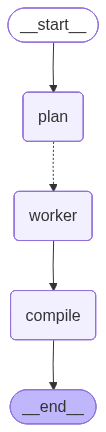

In [14]:
# --- 5. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# --- 6. RUN & TEST ---
result = graph.invoke(
    {
        "topic": "Memory in Agents",
        "subtopics": [],
        "summaries": [],
        "final_report": "",
    }
)
print("\n" + result["final_report"])

[plan] 5 subtopics → parallel workers
  [worker] Done: Types of Memory in Artificial Agents
  [worker] Done: Memory Retrieval Techniques in Intelligent Systems
  [worker] Done: The Impact of Memory on Decision Making in Agents
  [worker] Done: Memory Challenges in Machine Learning Algorithms
  [worker] Done: Comparative Analysis of Memory Models in Robotics and AI

📋 REPORT: Memory in Agents
  [1] Types of Memory in Artificial Agents [Content for: Types of Memory in Artificial Agents]
  [2] Memory Retrieval Techniques in Intelligent Systems [Content for: Memory Retrieval Techniques in Intelligent Systems]
  [3] The Impact of Memory on Decision Making in Agents [Content for: The Impact of Memory on Decision Making in Agents]
  [4] Memory Challenges in Machine Learning Algorithms [Content for: Memory Challenges in Machine Learning Algorithms]
  [5] Comparative Analysis of Memory Models in Robotics and AI [Content for: Comparative Analysis of Memory Models in Robotics and AI]
